# Visual Intelligence System — Model Combination

This notebook combines the trained YOLO object detection model
with the trained scene classification model.

The goal is to take a single input image and produce:

1. The objects detected in the image.
2. The predicted scene/category of the image.
3. A combined visual interpretation of the image.

The YOLO model is responsible for object detection, while the
scene classification model is responsible for understanding the
overall scene.

## Project Architecture

The system follows a two-model pipeline:

Input Image
     │
     ├───────────────┐
     ↓               ↓
YOLO Detector    Scene Classifier
     │               │
     ↓               ↓
Detected Objects   Scene Prediction
     │               │
     └───────┬───────┘
             ↓
      Combined Result

The two models perform different tasks:

- YOLO → "What objects are present?"
- Scene Classifier → "What type of scene is this?"

In [1]:
import os
import numpy

import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO



## Load Trained Models

The models were trained separately during the earlier stages
of the project.

We now load the saved model weights instead of training them again.

- YOLO model → object detection
- Scene classification model → scene recognition

In [2]:
YOLO_MODEL_PATH ="../models/yolo_detector.pt"

In [3]:
SCENE_MODEL_PATH = SCENE_MODEL_PATH = "../models/scene_classifier_efficientnetb0_finetuned.keras"

In [4]:
yolo_model = YOLO(YOLO_MODEL_PATH)

print("YOLO model loaded successfully!")

YOLO model loaded successfully!


In [5]:
import tensorflow as tf

In [6]:
scene_model = tf.keras.models.load_model(SCENE_MODEL_PATH)

print("Scene classifier loaded successfully!")

Scene classifier loaded successfully!


## Scene Class Labels

The scene classification model was trained on six scene categories.

The class indices were obtained from the original training
pipeline and must remain unchanged during inference.

The mapping is:

- 0 → buildings
- 1 → forest
- 2 → glacier
- 3 → mountain
- 4 → sea
- 5 → street

This mapping allows us to correctly interpret the output
probabilities produced by the scene classification model.

In [7]:
scene_classes = [
    "buildings",
    "forest",
    "glacier",
    "mountain",
    "sea",
    "street"
]

## Input Image

We now provide an image to the combined system.

The same image will be passed independently to both models:

- YOLO will detect objects.
- The scene classifier will predict the overall scene.

In [8]:
IMAGE_PATH = "../images/test_image.png"

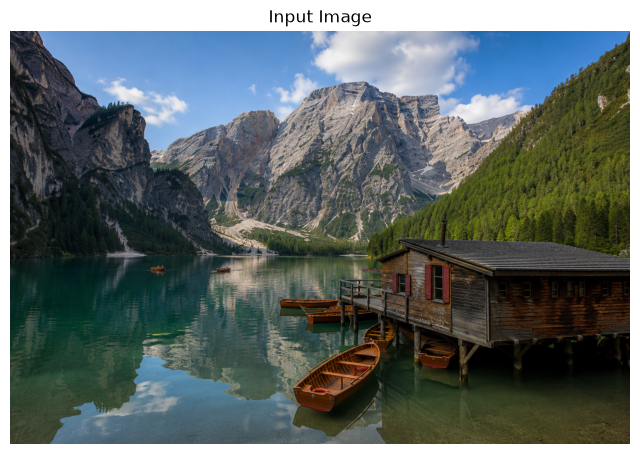

In [9]:
image = Image.open(IMAGE_PATH)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

## Object Detection

The YOLO detector identifies individual objects present in the image
and returns their bounding boxes, class labels, and confidence scores.

In [10]:
yolo_results = yolo_model(
    IMAGE_PATH,
    conf=0.4
)


image 1/1 c:\Users\DELL\OneDrive\Documents\ML-Projects\visual_intelligence_system\notebooks\..\images\test_image.png: 448x640 2 boats, 1261.0ms
Speed: 17.6ms preprocess, 1261.0ms inference, 29.5ms postprocess per image at shape (1, 3, 448, 640)


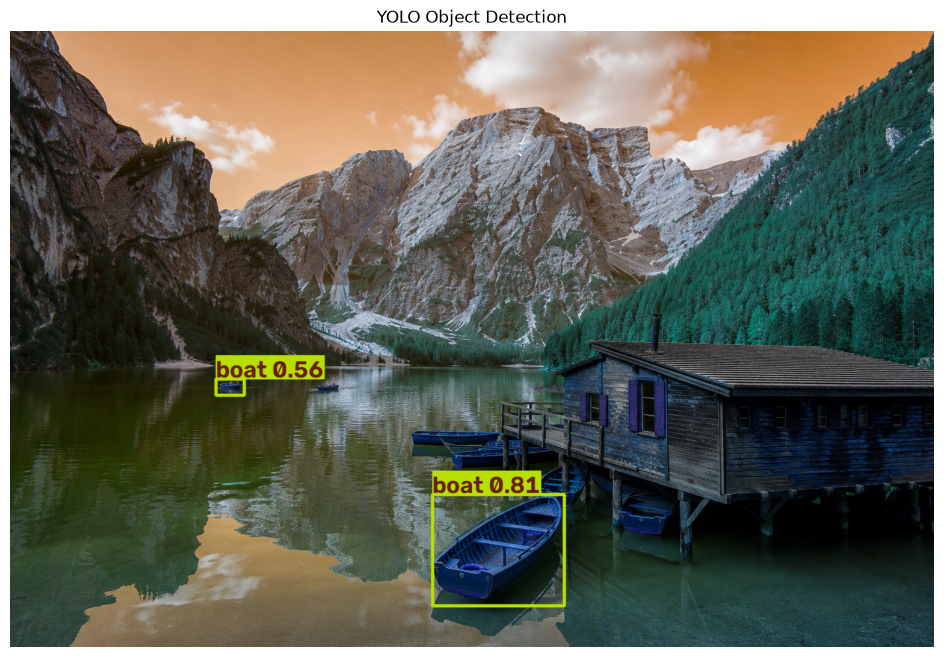

In [11]:
annotated_image = yolo_results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(annotated_image)
plt.axis("off")
plt.title("YOLO Object Detection")
plt.show()

## Scene Classification with EfficientNetB0

We now pass the same test image to the trained EfficientNetB0 model.

While YOLO identifies individual objects, EfficientNet predicts the overall scene category.

The model was trained on six scene classes:
- buildings
- forest
- glacier
- mountain
- sea
- street

In [12]:
import numpy as np

In [13]:
from tensorflow.keras.utils import load_img, img_to_array

img = load_img(
    IMAGE_PATH,
    target_size=(150, 150)
)

img_array = img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

print("Image prepared:", img_array.shape)

Image prepared: (1, 150, 150, 3)


In [14]:
scene_predictions = scene_model.predict(img_array)

scene_predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


array([[  0.0026931,     0.69878,     0.01921,     0.21201,    0.035326,    0.031981]], dtype=float32)

In [15]:
predicted_index = np.argmax(scene_predictions[0])

predicted_scene = scene_classes[predicted_index]

scene_confidence = scene_predictions[0][predicted_index]

print("Predicted scene:", predicted_scene)
print("Confidence:", scene_confidence)

Predicted scene: forest
Confidence: 0.69878036


In [16]:
for class_name ,prob in zip(
    scene_classes,
    scene_predictions[0]
):
    print(f"{class_name} : {prob:.4f} ")

buildings : 0.0027 
forest : 0.6988 
glacier : 0.0192 
mountain : 0.2120 
sea : 0.0353 
street : 0.0320 


In [30]:
def analyze_image(image_path):

    # ==========================================
    # 1. YOLO OBJECT DETECTION
    # ==========================================

    yolo_results = yolo_model(
        image_path,
        conf=0.4
    )

    result = yolo_results[0]

    # ==========================================
    # 2. SCENE CLASSIFICATION
    # ==========================================

    img = load_img(
        image_path,
        target_size=(150, 150)
    )

    img_array = img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # IMPORTANT:
    # Do NOT divide by 255.
    # The EfficientNet model already handles
    # the required input scaling.
    
    scene_predictions = scene_model.predict(
        img_array,
        verbose=0
    )

    predicted_index = np.argmax(scene_predictions[0])

    predicted_scene = scene_classes[predicted_index]

    scene_confidence = float(
        scene_predictions[0][predicted_index]
    )

    # ==========================================
    # 3. EXTRACT OBJECT DETECTIONS
    # ==========================================

    detected_objects = []

    for conf, cls in zip(
        result.boxes.conf.cpu().numpy(),
        result.boxes.cls.cpu().numpy()
    ):

        class_name = yolo_model.names[int(cls)]

        detected_objects.append({
            "class": class_name,
            "confidence": float(conf)
        })

    # ==========================================
    # 4. DISPLAY FINAL RESULT
    # ==========================================

    print("=" * 50)
    print("       VISUAL INTELLIGENCE SYSTEM")
    print("=" * 50)

    print("\nSCENE")
    print(f"  {predicted_scene}")
    print(f"  Confidence: {scene_confidence:.2%}")

    print("\nOBJECTS")

    if detected_objects:

        for obj in detected_objects:
            print(
                f"  {obj['class']:<12} "
                f"{obj['confidence']:.2f}"
            )

    else:
        print("  No objects detected.")

    print(
        f"\nTotal objects detected: "
        f"{len(detected_objects)}"
    )

    print("=" * 50)

    # ==========================================
    # 5. DISPLAY IMAGE
    # ==========================================

    annotated_image = result.plot()

    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_image[:, :, ::-1])
    plt.axis("off")
    plt.title(
        f"Scene: {predicted_scene} "
        f"({scene_confidence:.2%})"
    )
    plt.show()

    # ==========================================
    # 6. RETURN STRUCTURED RESULTS
    # ==========================================

    return {
        "scene": predicted_scene,
        "scene_confidence": scene_confidence,
        "objects": detected_objects,
        "object_count": len(detected_objects)
    }

In [31]:
test_images = [
    "../images/image2.png",
    "../images/image3.jpg",
    "../images/image4.jpg",
    "../images/image5.jpg"

]


image 1/1 c:\Users\DELL\OneDrive\Documents\ML-Projects\visual_intelligence_system\notebooks\..\images\image2.png: 448x640 1 bicycle, 1 bus, 5 cars, 4 persons, 129.6ms
Speed: 3.6ms preprocess, 129.6ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)
       VISUAL INTELLIGENCE SYSTEM

SCENE
  street
  Confidence: 99.98%

OBJECTS
  person       0.97
  person       0.95
  bus          0.95
  person       0.90
  car          0.88
  car          0.86
  car          0.70
  bicycle      0.65
  car          0.57
  person       0.48
  car          0.46

Total objects detected: 11


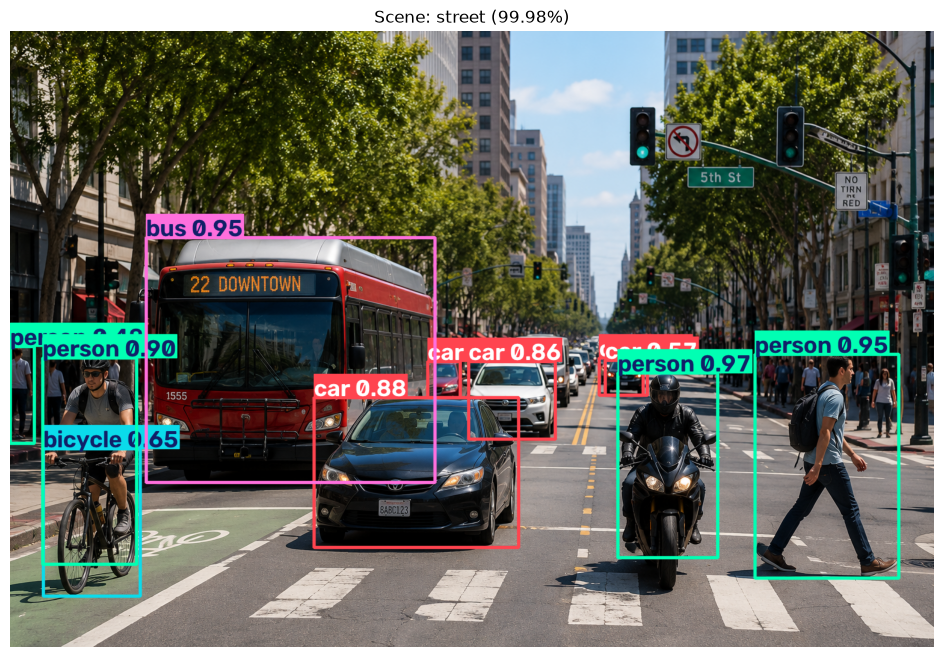


image 1/1 c:\Users\DELL\OneDrive\Documents\ML-Projects\visual_intelligence_system\notebooks\..\images\image3.jpg: 640x448 1 boat, 1 person, 129.2ms
Speed: 2.8ms preprocess, 129.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 448)
       VISUAL INTELLIGENCE SYSTEM

SCENE
  sea
  Confidence: 100.00%

OBJECTS
  person       0.84
  boat         0.76

Total objects detected: 2


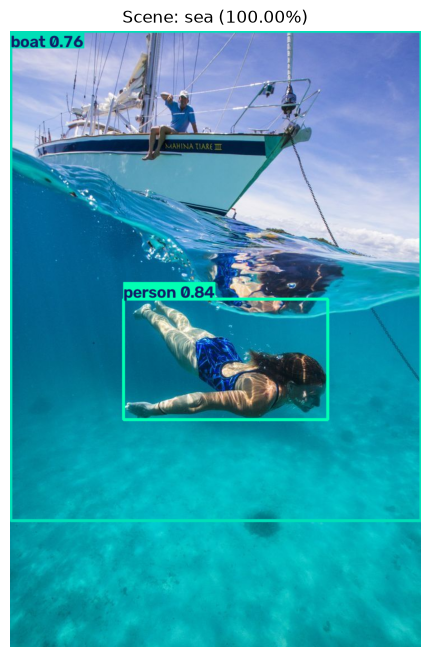


image 1/1 c:\Users\DELL\OneDrive\Documents\ML-Projects\visual_intelligence_system\notebooks\..\images\image4.jpg: 640x448 4 persons, 181.5ms
Speed: 2.3ms preprocess, 181.5ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 448)
       VISUAL INTELLIGENCE SYSTEM

SCENE
  forest
  Confidence: 91.76%

OBJECTS
  person       0.95
  person       0.95
  person       0.88
  person       0.69

Total objects detected: 4


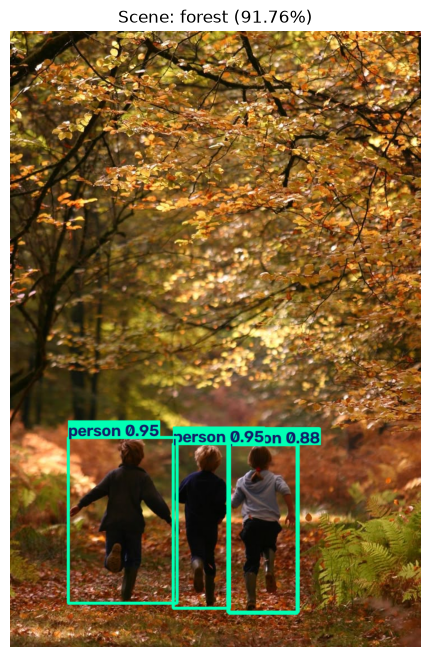


image 1/1 c:\Users\DELL\OneDrive\Documents\ML-Projects\visual_intelligence_system\notebooks\..\images\image5.jpg: 640x384 1 person, 1 pottedplant, 131.2ms
Speed: 5.0ms preprocess, 131.2ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 384)
       VISUAL INTELLIGENCE SYSTEM

SCENE
  buildings
  Confidence: 99.99%

OBJECTS
  pottedplant  0.78
  person       0.45

Total objects detected: 2


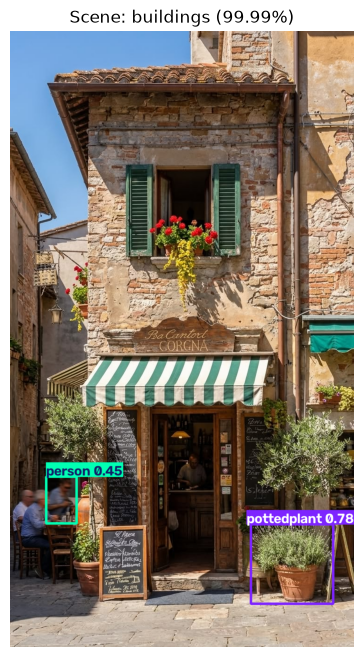

In [32]:
for image in test_images:
    analyze_image(image)

# Final Visual Intelligence System

The final system combines two independently trained deep learning
models to provide both scene-level and object-level understanding
of an image.

### Scene Classification

A fine-tuned EfficientNetB0 model classifies the overall scene into
one of six categories:

- Buildings
- Forest
- Glacier
- Mountain
- Sea
- Street

### Object Detection

A YOLO object detection model identifies individual objects within
the image and provides:

- Object class
- Confidence score
- Bounding-box location

### Combined Pipeline

Both models receive the same input image.

The scene classifier determines the overall environment, while YOLO
identifies the individual objects present in that environment.

This allows the system to produce a richer interpretation than
either model could provide independently.

## Qualitative Testing

The combined system was tested on several representative images
covering different scene categories.

| Scene | Scene Prediction | Confidence | Objects Detected |
|---|---|---:|---:|
| Urban street | Street | 99.98% | 11 |
| Ocean scene | Sea | 100.00% | 2 |
| Forest scene | Forest | 91.76% | 4 |
| Town/building scene | Buildings | 99.99% | 2 |

The system correctly identified the scene category in all four
qualitative test cases.

YOLO also successfully detected multiple objects within the
different scenes.

## Limitations

Although the combined system performs well on the evaluated examples,
several limitations remain.

1. Scene classification is limited to six predefined scene categories.

2. YOLO performance depends on the object classes represented in the
   training dataset.

3. Small, distant, partially occluded, or unusual objects may be
   detected with lower confidence.

4. Scene classification may become difficult when an image contains
   visual characteristics belonging to multiple scene categories.

5. The qualitative test images do not represent a formal benchmark;
   therefore, their results should not be interpreted as the overall
   model accuracy.

# Conclusion

This project developed a combined visual intelligence system using
two complementary deep learning approaches.

A fine-tuned EfficientNetB0 model was used for scene classification,
while YOLO was used for object detection.

The final pipeline accepts a single image and produces both:

- the predicted scene and its confidence
- multiple detected objects and their confidence scores

The project also included exploratory data analysis, transfer learning,
fine-tuning, object-detection training, evaluation, error analysis,
and qualitative testing.

The results demonstrate that combining scene-level classification with
object-level detection can provide a richer understanding of visual
content than using either task independently.

Future improvements could include adding more scene categories,
training on a larger and more diverse dataset, improving detection of
small objects, and deploying the combined pipeline as an interactive
application.